# Machine Learning — Introduction, EDA, Data Cleaning & Preprocessing

This notebook is a practical study guide built around the uploaded **Machine Learning (2).pdf** and the requested ML workflow.

> **Source coverage from the PDF:** ML definition and examples, AI vs ML vs DL, supervised/unsupervised/reinforcement learning, the end-to-end ML workflow, EDA, data cleaning, preprocessing, feature engineering, and feature selection.

The PDF's workflow is:
1. Problem definition
2. Data collection
3. Exploratory Data Analysis (EDA)
4. Data preprocessing / cleaning
5. Feature selection & engineering
6. Dataset split
7. Model selection
8. Model training
9. Model evaluation
10. Hyperparameter tuning
11. Model testing / validation

This notebook focuses especially on **steps 3–5**, with executable Python examples.

## 1. What is Machine Learning?

**Machine Learning (ML)** is a way of building systems that learn patterns from data so that they can make predictions or decisions without us manually writing every rule.

### Traditional programming vs ML

| Traditional Programming | Machine Learning |
|---|---|
| Rules + data → result | Data + known results → learned model/rules |
| Logic is written manually | Patterns are learned from examples |
| Good when rules are explicit | Useful when patterns are difficult to hand-code |

### Examples
- YouTube/video recommendations
- Spam detection
- Voice assistants
- Face recognition
- Self-driving systems

The central idea is:

**Data → learn patterns → model → prediction/decision**

## 2. AI vs ML vs Deep Learning

Think of these as nested areas:

**Artificial Intelligence (AI)** → broad field of making machines perform tasks associated with intelligence.

**Machine Learning (ML)** → a subset of AI where systems learn patterns from data.

**Deep Learning (DL)** → a subset of ML based mainly on multi-layer neural networks.

Examples:
- AI: a system that plays chess.
- ML: a spam classifier learned from labeled emails.
- DL: image/face recognition using neural networks.

## 3. Types of Machine Learning

### Supervised Learning
The training data contains inputs **and** known outputs/labels.

Example:

| Income | Credit Score | Loan |
|---:|---:|---|
| 40000 | 750 | Yes |
| 25000 | 600 | No |

Common algorithms: Linear Regression, Logistic Regression, Decision Trees, Naive Bayes, KNN, SVM, Gradient Boosting.

### Unsupervised Learning
There is no target label to predict. We discover structure or patterns.

Examples:
- Clustering customers
- Finding unusual observations
- Dimensionality reduction

### Reinforcement Learning
An agent interacts with an environment and learns through rewards/penalties, using trial and error.

# Part A — The Complete ML Workflow

The workflow is not simply "train a model". Data understanding and preparation come first.

### 1. Problem Definition
Clearly define:
- What are we predicting?
- What is the target?
- Is it classification, regression, clustering, etc.?
- What does success mean?

### 2. Data Collection
Obtain relevant data from databases, files, APIs, sensors, surveys, logs, etc.

### 3. EDA
Explore structure, quality, distributions, relationships, missingness, anomalies and the target.

### 4. Cleaning / Preprocessing
Fix data-quality problems and transform valid data into a model-ready representation.

### 5. Feature Engineering / Selection
Create useful signals and remove irrelevant or redundant features.

### 6–11. Split → Select Model → Train → Evaluate → Tune → Test/Validate

**Important:** preprocessing decisions should be learned from the training data to avoid data leakage.

# Part B — EDA (Exploratory Data Analysis)

The uploaded PDF defines EDA as the process of **analyzing, visualizing and understanding data before building a machine-learning model**.

Think of EDA as detective work:
- Understand the dataset
- Discover patterns
- Spot anomalies
- Generate insights
- Decide what to do next

A useful EDA checklist:
1. View the data
2. Summary statistics
3. Value counts
4. Missing-value analysis
5. Visualizations
6. Target-variable exploration

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 4. Create a small practice dataset

In [25]:
# Synthetic dataset so the notebook runs without downloading anything.

df = pd.DataFrame({
    "age": [21, 25, 32, 40, 29, 35, np.nan, 52, 28, 31, 40],
    "income": [25000, 32000, 48000, 72000, 45000, 65000, 51000, 120000, 42000, 50000, 72000],
    "experience": [0, 2, 7, 15, 5, 10, 8, 25, 4, 6, 15],
    "city": ["Delhi", "delhi", "Mumbai", "Delhi", "Pune", "Mumbai", "Delhi", "Pune", "Delhi", "Mumbai", "Delhi"],
    "education": ["UG", "UG", "PG", "PG", "UG", "PG", "UG", "PG", "UG", "UG", "PG"],
    "target_salary": [30000, 38000, 55000, 85000, 52000, 78000, 60000, 150000, 50000, 62000, 85000]
})

# Add a duplicate row deliberately so that we can demonstrate cleaning.
df = pd.concat([df, df.iloc[[3]]], ignore_index=True)

df


,age,income,experience,city,education,target_salary
0,21.00,25000,0,Delhi,UG,30000
1,25.00,32000,2,delhi,UG,38000
2,32.00,48000,7,Mumbai,PG,55000
3,40.00,72000,15,Delhi,PG,85000
4,29.00,45000,5,Pune,UG,52000
5,35.00,65000,10,Mumbai,PG,78000
6,NaN,51000,8,Delhi,UG,60000
7,52.00,120000,25,Pune,PG,150000
8,28.00,42000,4,Delhi,UG,50000
9,31.00,50000,6,Mumbai,UG,62000


## 5. EDA Step 1 — View the data

In [26]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()


First 5 rows:


,age,income,experience,city,education,target_salary
0,21.00,25000,0,Delhi,UG,30000
1,25.00,32000,2,delhi,UG,38000
2,32.00,48000,7,Mumbai,PG,55000
3,40.00,72000,15,Delhi,PG,85000
4,29.00,45000,5,Pune,UG,52000



Last 5 rows:


,age,income,experience,city,education,target_salary
7,52.00,120000,25,Pune,PG,150000
8,28.00,42000,4,Delhi,UG,50000
9,31.00,50000,6,Mumbai,UG,62000
10,40.00,72000,15,Delhi,PG,85000
11,40.00,72000,15,Delhi,PG,85000



Shape: (12, 6)

Columns:
['age', 'income', 'experience', 'city', 'education', 'target_salary']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            11 non-null     float64
 1   income         12 non-null     int64  
 2   experience     12 non-null     int64  
 3   city           12 non-null     str    
 4   education      12 non-null     str    
 5   target_salary  12 non-null     int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 795.0 bytes


### What to ask here?
- How many rows and columns exist?
- What does each column represent?
- Which columns are numerical?
- Which are categorical?
- Is the target present?
- Are there suspicious names, values or formats?

## 6. EDA Step 2 — Summary statistics

In [27]:
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,11.00,NaN,NaN,NaN,33.91,8.70,21.00,28.50,32.00,40.00,52.00
income,12.00,NaN,NaN,NaN,"57,833.33","25,015.75","25,000.00","44,250.00","50,500.00","72,000.00","120,000.00"
experience,12.00,NaN,NaN,NaN,9.33,7.06,0.00,4.75,7.50,15.00,25.00
city,12,4,Delhi,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,12,2,UG,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_salary,12.00,NaN,NaN,NaN,"69,166.67","31,431.99","30,000.00","51,500.00","61,000.00","85,000.00","150,000.00"


For numerical variables, pay attention to:
- mean and median
- standard deviation
- minimum and maximum
- quartiles

These help reveal central tendency, spread and potentially unusual values.

## 7. EDA Step 3 — Value counts

In [28]:
for col in ["city", "education"]:
    print(f"--- {col} ---")
    display(df[col].value_counts(dropna=False))


--- city ---


city
Delhi     6
Mumbai    3
Pune      2
delhi     1
Name: count, dtype: int64

--- education ---


education
UG    6
PG    6
Name: count, dtype: int64

Value counts are especially useful for categorical variables.

They can expose inconsistent categories such as:
`Delhi`, `delhi`, `DELHI`.

These should usually represent the same category if the capitalization difference is accidental.

## 8. EDA Step 4 — Missing-value analysis

In [29]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing)


,missing_count,missing_percent
age,1,8.33
income,0,0.00
experience,0,0.00
city,0,0.00
education,0,0.00
target_salary,0,0.00


Do not automatically delete missing rows.

First ask:
- How many values are missing?
- Which columns are affected?
- Is the missingness meaningful?
- Would dropping rows remove too much data?
- Should we impute using mean/median/mode or a more advanced method?

The uploaded PDF lists mean/median for numerical data, mode for categorical data, and advanced methods such as regression/KNN/interpolation as possibilities.

## 9. EDA Step 5 — Duplicate analysis

In [30]:
print("Duplicate rows:", df.duplicated().sum())
display(df[df.duplicated(keep=False)].sort_values(list(df.columns)))


Duplicate rows: 2


,age,income,experience,city,education,target_salary
3,40.00,72000,15,Delhi,PG,85000
10,40.00,72000,15,Delhi,PG,85000
11,40.00,72000,15,Delhi,PG,85000


## 10. EDA Step 6 — Visualizations

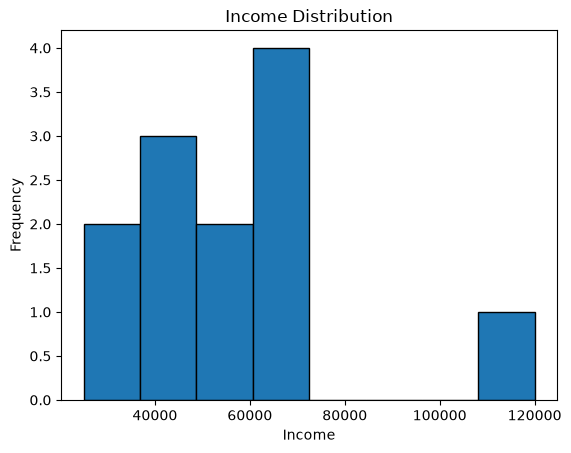

In [31]:
# Histogram: distribution
df["income"].plot(kind="hist", bins=8, edgecolor="black")
plt.title("Income Distribution")
plt.xlabel("Income")
plt.show()


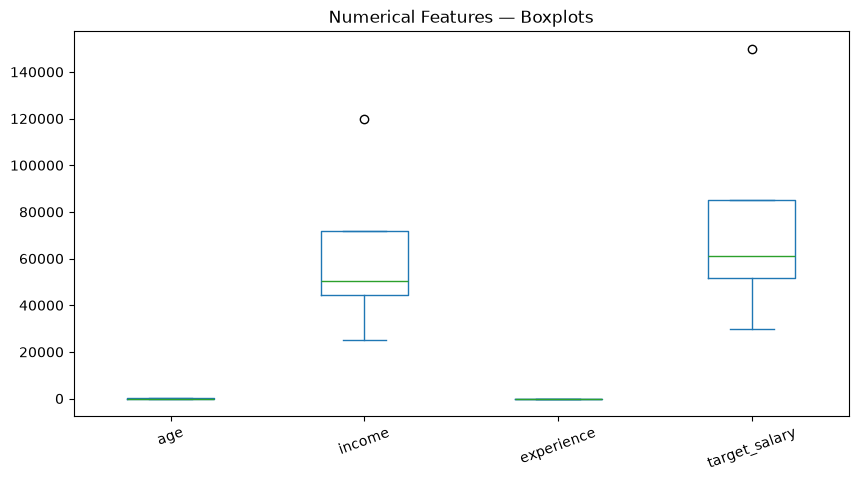

In [32]:
# Boxplot: spread and potential outliers
df[["age", "income", "experience", "target_salary"]].plot(
    kind="box", figsize=(10, 5), rot=20
)
plt.title("Numerical Features — Boxplots")
plt.show()


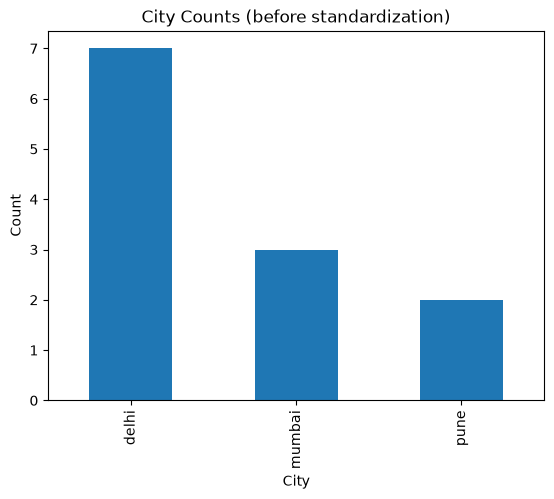

In [33]:
# Bar plot: category counts
df["city"].str.lower().value_counts().plot(kind="bar")
plt.title("City Counts (before standardization)")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()


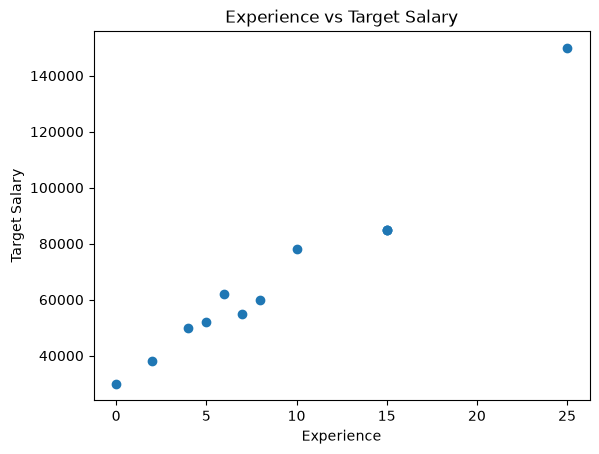

In [34]:
# Scatter plot: relationship between two numerical variables
plt.scatter(df["experience"], df["target_salary"])
plt.xlabel("Experience")
plt.ylabel("Target Salary")
plt.title("Experience vs Target Salary")
plt.show()


### Visualization guide

| Plot | Main purpose |
|---|---|
| Histogram | Distribution of a numerical variable |
| Boxplot | Spread and possible outliers |
| Bar plot | Compare categorical frequencies |
| Scatter plot | Relationship between two numerical variables |
| Correlation heatmap | Linear relationships among numerical variables |

The PDF specifically highlights these visualization roles.

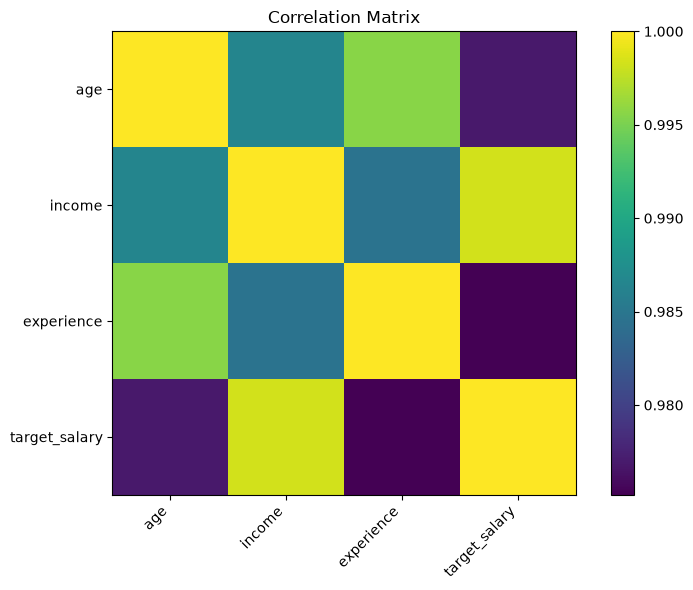

In [35]:
# Correlation among numerical features
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 11. EDA Step 6 — Target-variable exploration

For supervised learning, investigate how the target relates to the predictors.

Examples:
- numerical target → distribution, outliers, relationship with numerical features
- categorical target → class balance and relationships with predictors

This step helps determine what transformations, features or evaluation strategy may be appropriate.

# Part C — Data Cleaning

The uploaded PDF distinguishes cleaning from preprocessing:

**Data cleaning = fixing mistakes/problems in the data.**

The PDF covers:
1. Missing values
2. Duplicate rows
3. Wrong data types
4. Inconsistent categories
5. Outliers
6. Logic/domain errors

A useful mental model:

> **EDA tells you what is wrong; cleaning fixes identified data-quality problems.**

## 12. Cleaning Step 1 — Missing values

In [36]:
# Example: median imputation for a numerical column
df_clean = df.copy()

median_age = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(median_age)

print("Remaining missing values:")
display(df_clean.isna().sum())


Remaining missing values:


age              0
income           0
experience       0
city             0
education        0
target_salary    0
dtype: int64

Typical choices:
- Numerical → mean or median
- Categorical → mode
- Drop rows/columns → only when justified, e.g. very few affected rows or an unusable column
- More advanced → KNN, regression or interpolation where appropriate

**Important:** in a real ML pipeline, fit the imputer on the training set only.

## 13. Cleaning Step 2 — Remove duplicates

In [37]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
after = len(df_clean)

print("Rows before:", before)
print("Rows after :", after)


Rows before: 12
Rows after : 10


## 14. Cleaning Step 3 — Fix data types

In [38]:
# Example patterns:
# df["age"] = pd.to_numeric(df["age"], errors="coerce")
# df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(df_clean.dtypes)


age              float64
income             int64
experience         int64
city                 str
education            str
target_salary      int64
dtype: object


## 15. Cleaning Step 4 — Standardize inconsistent categories

In [39]:
df_clean["city"] = df_clean["city"].str.strip().str.lower()

display(df_clean["city"].value_counts())


city
delhi     5
mumbai    3
pune      2
Name: count, dtype: int64

The PDF's examples include converting variants such as:
- `Male`, `male`, `MALE` → one consistent form
- `Yes`, `yes`, `Y` → one consistent representation

The exact normalization rule depends on the meaning of the data.

## 16. Cleaning Step 5 — Detect outliers

In [40]:
# IQR-based detection
Q1 = df_clean["income"].quantile(0.25)
Q3 = df_clean["income"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean["income"] < lower) | (df_clean["income"] > upper)]

print("Lower bound:", lower)
print("Upper bound:", upper)
display(outliers)


Lower bound: 14625.0
Upper bound: 89625.0


,age,income,experience,city,education,target_salary
7,52.00,120000,25,pune,PG,150000


Outliers are not automatically errors.

Possible actions:
- Remove them if they are clearly invalid
- Cap/winsorize them when appropriate
- Transform the feature
- Keep them if they are genuine observations

The PDF mentions boxplots, IQR and z-score as detection approaches and removal/capping as possible treatments.

## 17. Cleaning Step 6 — Domain/logic validation

In [41]:
# Example rules. Real rules depend on the domain.
invalid_age = df_clean[(df_clean["age"] < 0) | (df_clean["age"] > 120)]
invalid_experience = df_clean[
    (df_clean["experience"] < 0) |
    (df_clean["experience"] > df_clean["age"])
]

print("Invalid ages:")
display(invalid_age)

print("Potentially invalid experience values:")
display(invalid_experience)


Invalid ages:


,age,income,experience,city,education,target_salary


Potentially invalid experience values:


,age,income,experience,city,education,target_salary


Examples from the PDF include values such as negative age or an implausibly large BMI. These are domain errors and should be investigated rather than blindly treated as ordinary statistical outliers.

# Part D — Data Preprocessing

The uploaded PDF describes preprocessing as preparing **valid/clean data** so that it can be analyzed or used by an ML model.

Think:

**Cleaning → fix bad data**

**Preprocessing → transform good data into a useful model-ready representation**

## 18. Encoding categorical variables

### Label/ordinal encoding
Use when categories have a meaningful order.

Example:
- Low → 0
- Medium → 1
- High → 2

### One-hot encoding
Use for nominal categories without an inherent order.

Example:
`city = Delhi, Mumbai, Pune`

becomes:
- city_Delhi
- city_Mumbai
- city_Pune

Avoid assigning arbitrary numbers such as Delhi=0, Mumbai=1, Pune=2 when those numbers would imply an order.

In [42]:
# One-hot encoding example
encoded = pd.get_dummies(df_clean, columns=["city", "education"], dtype=int)
display(encoded.head())


,age,income,experience,target_salary,city_delhi,city_mumbai,city_pune,education_PG,education_UG
0,21.00,25000,0,30000,1,0,0,0,1
1,25.00,32000,2,38000,1,0,0,0,1
2,32.00,48000,7,55000,0,1,0,1,0
3,40.00,72000,15,85000,1,0,0,1,0
4,29.00,45000,5,52000,0,0,1,0,1


## 19. Feature transformation

In [43]:
# Log transformation can reduce strong right skew for positive-valued features.
df_transformed = df_clean.copy()
df_transformed["income_log"] = np.log1p(df_transformed["income"])

display(df_transformed[["income", "income_log"]].head())


,income,income_log
0,25000,10.13
1,32000,10.37
2,48000,10.78
3,72000,11.18
4,45000,10.71


Other transformations can include:
- square root
- logarithm
- power transformations

Use them when the data distribution or model assumptions make them useful. Do not transform a feature just because a transformation exists.

## 20. Feature scaling

### Min-Max normalization

Transforms values to a chosen range, commonly [0, 1]:

**x' = (x - min(x)) / (max(x) - min(x))**

### Standardization / Z-score

Transforms a feature so that it is centered around mean 0 with standard deviation 1:

**z = (x - μ) / σ**

Scaling is particularly useful for distance-based algorithms and many optimization-based models.

In [44]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

numeric_cols = ["age", "income", "experience"]

X_num = df_clean[numeric_cols].copy()

# Fill missing values first for this demonstration.
X_num["age"] = X_num["age"].fillna(X_num["age"].median())

minmax = MinMaxScaler()
standard = StandardScaler()

X_minmax = minmax.fit_transform(X_num)
X_standard = standard.fit_transform(X_num)

print("Min-Max scaled:")
display(pd.DataFrame(X_minmax, columns=numeric_cols).head())

print("Standardized:")
display(pd.DataFrame(X_standard, columns=numeric_cols).head())


Min-Max scaled:


,age,income,experience
0,0.00,0.00,0.00
1,0.13,0.07,0.08
2,0.35,0.24,0.28
3,0.61,0.49,0.60
4,0.26,0.21,0.20


Standardized:


,age,income,experience
0,-1.41,-1.19,-1.19
1,-0.92,-0.91,-0.90
2,-0.06,-0.28,-0.17
3,0.92,0.67,0.99
4,-0.43,-0.40,-0.47


# Part E — Feature Engineering & Feature Selection

### Feature Engineering
Create new features or transform existing features to expose useful patterns.

Examples from the PDF:
- Mathematical combinations
- Target-based flags
- Binning when useful
- Time-based features when time exists

Example:
`income_per_experience = income / (experience + 1)`

### Feature Selection
Select useful features and remove unnecessary ones.

Benefits:
- Less noise
- Potentially less overfitting
- Faster training
- Easier interpretation

Methods mentioned in the PDF:
- Filter: correlation matrix, chi-square, ANOVA F-test
- Embedded: Lasso, tree-based feature importance

In [45]:
# Simple feature engineering example
df_fe = df_clean.copy()
df_fe["income_per_experience"] = df_fe["income"] / (df_fe["experience"] + 1)

display(df_fe[["income", "experience", "income_per_experience"]].head())


,income,experience,income_per_experience
0,25000,0,"25,000.00"
1,32000,2,"10,666.67"
2,48000,7,"6,000.00"
3,72000,15,"4,500.00"
4,45000,5,"7,500.00"


# Part F — Avoiding Data Leakage

A critical practical rule:

### Split first, learn preprocessing from training data

Bad pattern:
1. Combine train + test
2. Calculate median/scaler/encoding using all data
3. Split

Better pattern:
1. Split into train/test
2. Fit imputer/scaler/encoder on training data
3. Transform training and test using the fitted objects

For real projects, use `sklearn.pipeline.Pipeline` and `ColumnTransformer` so this order is enforced.

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Example supervised setup
X = df.drop(columns=["target_salary"])
y = df["target_salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_features = ["age", "income", "experience"]
categorical_features = ["city", "education"]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

print("Train transformed shape:", X_train_ready.shape)
print("Test transformed shape :", X_test_ready.shape)


Train transformed shape: (9, 9)
Test transformed shape : (3, 9)


# Final ML Data-Preparation Checklist

Before training a model, ask:

### EDA
- [ ] Shape checked
- [ ] Columns understood
- [ ] Data types checked
- [ ] Summary statistics checked
- [ ] Categorical frequencies checked
- [ ] Missingness analyzed
- [ ] Duplicates checked
- [ ] Distributions visualized
- [ ] Outliers investigated
- [ ] Relationships/correlation explored
- [ ] Target analyzed

### Cleaning
- [ ] Missing values handled
- [ ] Duplicates handled
- [ ] Wrong data types fixed
- [ ] Inconsistent categories standardized
- [ ] Outliers investigated/handled
- [ ] Domain/logic errors checked

### Preprocessing
- [ ] Train/test split handled correctly
- [ ] Categorical features encoded
- [ ] Skewed features transformed where justified
- [ ] Numerical features scaled when appropriate
- [ ] Feature engineering performed where useful
- [ ] Feature selection considered
- [ ] Leakage prevented

### Then
**Model selection → training → evaluation → tuning → final testing/validation**

## Source note

The uploaded 60-page PDF is the primary source for the terminology and sequence used here. In particular:
- Pages 3–28: ML introduction, AI/ML/DL and ML types
- Page 30: complete ML workflow
- Pages 29–39: EDA
- Pages 40–47: data cleaning
- Pages 48–55: preprocessing
- Pages 56–60: feature engineering and feature selection

The linked YouTube video could not be retrieved reliably in this environment because the YouTube page fetch was throttled, so this notebook does **not** claim any video-specific material that could not be verified.